In [16]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
np.random.seed(1)

#### Frequentist Multilevel Model

In [3]:
# Simulation parameters

n_participants = 30
n_trials = 40

population_intercept = 650
condition_effect = 40

participant_sd = 50
residual_sd = 30

# Simulating dataset.

data = []

participant_intercepts = np.random.normal(
    population_intercept,
    participant_sd,
    n_participants,
)

for participant in range(n_participants):

    intercept = participant_intercepts[participant]

    for condition in ["Congruent", "Incongruent"]:

        for trial in range(n_trials):

            x = 0 if condition == "Congruent" else 1

            reaction_time = (
                intercept
                + condition_effect * x
                + np.random.normal(
                    0,
                    residual_sd,
                )
            )

            data.append(
                [
                    participant,
                    condition,
                    reaction_time,
                ]
            )

reaction_time_data = pd.DataFrame(
    data,
    columns=[
        "participant",
        "condition",
        "reaction_time",
    ],
)

In [4]:
# Summary statistics

print("Dataset\n", reaction_time_data.describe())

print("\nNumber of participants:", reaction_time_data["participant"].nunique(),)

print("Trials per participant:", n_trials * 2,)

Dataset
        participant  reaction_time
count  2400.000000    2400.000000
mean     14.500000     667.814800
std       8.657245      61.754549
min       0.000000     484.401266
25%       7.000000     625.099517
50%      14.500000     667.676585
75%      22.000000     710.118660
max      29.000000     895.998669

Number of participants: 30
Trials per participant: 80


In [9]:
# Frequentist Mixed-Effects Model

frequentist_model = smf.mixedlm(
    "reaction_time ~ C(condition)",
    data=reaction_time_data,
    groups="participant",
)

frequentist_results = frequentist_model.fit()

print("\nFrequentist model\n", frequentist_results.summary())


Frequentist model
                   Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      reaction_time
No. Observations:      2400         Method:                  REML         
No. Groups:            30           Scale:                   908.7474     
Min. group size:       80           Log-Likelihood:          -11656.3491  
Max. group size:       80           Converged:               Yes          
Mean group size:       80.0                                               
--------------------------------------------------------------------------
                             Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                    648.651    9.392 69.063 0.000 630.243 667.060
C(condition)[T.Incongruent]   38.327    1.231 31.143 0.000  35.915  40.739
participant Var             2623.684   23.090                             



#### Bayesian Multilevel Model

In [7]:
# Preparing data

participant_idx = reaction_time_data["participant"].values

condition = (reaction_time_data["condition"] == "Incongruent").astype(int)

reaction_time = reaction_time_data["reaction_time"].values

n_participants = reaction_time_data["participant"].nunique()

In [8]:
# Bayesian multilevel model

with pm.Model() as bayesian_model:

    mu_alpha = pm.Normal(
        "mu_alpha",
        mu=650,
        sigma=100,
    )

    sigma_alpha = pm.HalfNormal(
        "sigma_alpha",
        sigma=50,
    )

    alpha = pm.Normal(
        "alpha",
        mu=mu_alpha,
        sigma=sigma_alpha,
        shape=n_participants,
    )

    beta_condition = pm.Normal(
        "beta_condition",
        mu=0,
        sigma=50,
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=30,
    )

    mu = (
        alpha[participant_idx]
        + beta_condition * condition
    )

    pm.Normal(
        "reaction_time",
        mu=mu,
        sigma=sigma,
        observed=reaction_time,
    )

    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.95,
        random_seed=1,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha, beta_condition, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.


In [10]:
# Posterior summary

print(
    az.summary(
        trace,
        var_names=[
            "mu_alpha",
            "beta_condition",
            "sigma_alpha",
            "sigma",
        ],
    )
)

                   mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
mu_alpha        648.611  9.655  630.438  666.713      0.104    0.179   
beta_condition   38.317  1.224   36.094   40.644      0.018    0.016   
sigma_alpha      52.371  6.980   39.976   65.593      0.088    0.139   
sigma            30.152  0.450   29.346   31.047      0.005    0.008   

                ess_bulk  ess_tail  r_hat  
mu_alpha          8673.0    3033.0    1.0  
beta_condition    4390.0    3545.0    1.0  
sigma_alpha       7126.0    2949.0    1.0  
sigma             8428.0    3039.0    1.0  


#### Compare Frequentist and Bayesian Results

In [11]:
# Extracting estimates

frequentist_effect = frequentist_results.params["C(condition)[T.Incongruent]"]

bayesian_effect = (
    az.summary(trace, var_names=["beta_condition"],)
    .loc["beta_condition", "mean"]
)

comparison = pd.DataFrame(
    {
        "Method": ["Frequentist", "Bayesian",],
        "Condition Effect": [frequentist_effect, bayesian_effect,],
    }
)

print(comparison)

        Method  Condition Effect
0  Frequentist         38.327143
1     Bayesian         38.317000


#### Complete Mixed-Effects Analysis of a Stroop Experiment

In [22]:
# Loading dataset.

RAW_PATH = PROJECT_ROOT / "data" / "06-stroop-simulated.csv"

df = pd.read_csv(RAW_PATH)

In [23]:
# Inspecting dataset.

print(df.head())

print("\nDataset shape:", df.shape)

print("\nMissing values\n", df.isna().sum())

print("\nSummary statistics\n", df.describe())

   participant  condition  trial  reaction_time
0            1  Congruent      1         577.65
1            1  Congruent      2         615.73
2            1  Congruent      3         576.43
3            1  Congruent      4         445.75
4            1  Congruent      5         622.43

Dataset shape: (2400, 4)

Missing values
 participant      0
condition        0
trial            0
reaction_time    0
dtype: int64

Summary statistics
        participant        trial  reaction_time
count  2400.000000  2400.000000    2400.000000
mean     20.500000    15.500000     598.999071
std      11.545802     8.657245      93.061677
min       1.000000     1.000000     317.590000
25%      10.750000     8.000000     534.987500
50%      20.500000    15.500000     601.145000
75%      30.250000    23.000000     663.182500
max      40.000000    30.000000     898.000000


In [24]:
# Keeping valid trials.

data = df.copy()

data = data[
    data["condition"].isin(
        [
            "Congruent",
            "Neutral",
            "Incongruent",
        ]
    )
]

data = data[
    (data["reaction_time"] >= 200)
    &
    (data["reaction_time"] <= 2000)
]

In [34]:
# Descriptive statistics

print("Condition summaries\n", data.groupby("condition")["reaction_time"].describe())

Condition summaries
               count        mean        std     min       25%      50%  \
condition                                                               
Congruent    1200.0  552.062658  81.253566  317.59  495.7800  550.000   
Incongruent  1200.0  645.935483  79.475178  366.10  593.7875  647.735   

                  75%     max  
condition                      
Congruent    608.0975  850.13  
Incongruent  700.9975  898.00  


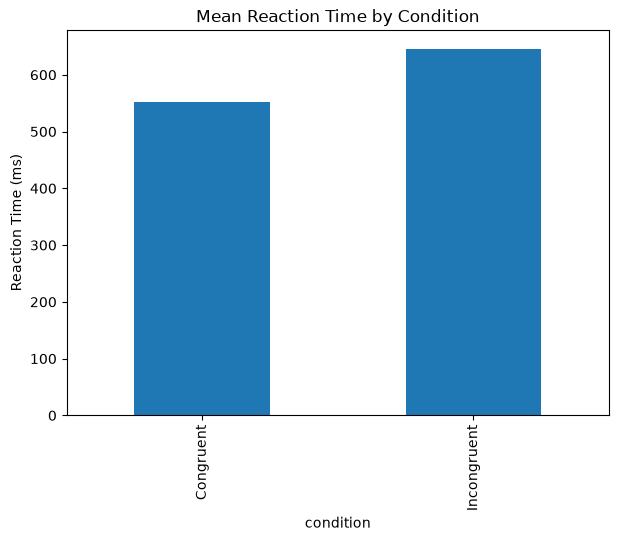

In [26]:
# Mean RT

plt.figure(figsize=(7, 5))

(
    data.groupby("condition")["reaction_time"]
    .mean()
    .plot(kind="bar")
)

plt.ylabel("Reaction Time (ms)")
plt.title("Mean Reaction Time by Condition")

plt.show()

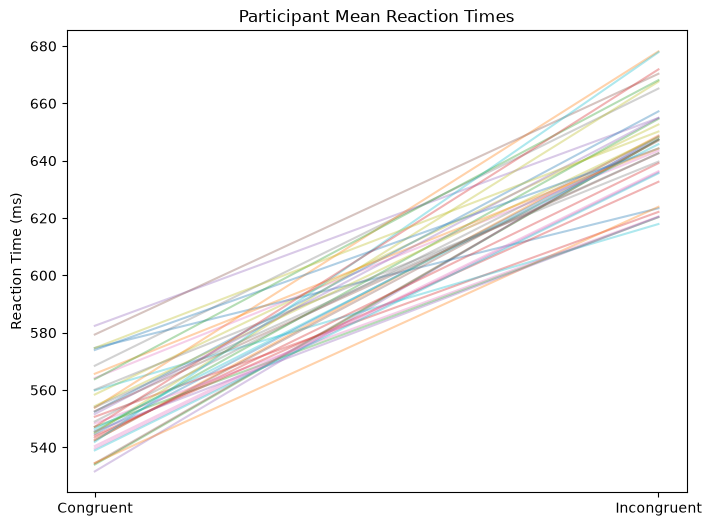

In [27]:
# Individual Participant Trajectories

participant_means = (
    data
    .groupby(
        [
            "participant",
            "condition",
        ]
    )["reaction_time"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 6))

for participant in participant_means["participant"].unique():

    participant_data = participant_means[
        participant_means["participant"]
        == participant
    ]

    plt.plot(
        participant_data["condition"],
        participant_data["reaction_time"],
        alpha=0.35,
    )

plt.ylabel("Reaction Time (ms)")
plt.title("Participant Mean Reaction Times")

plt.show()

In [28]:
# OLS Model

ols_model = smf.ols(
    "reaction_time ~ C(condition)",
    data=data,
).fit()

print("OLS Model\n", ols_model.summary())

OLS Model
                             OLS Regression Results                            
Dep. Variable:          reaction_time   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     818.6
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          3.85e-155
Time:                        17:52:33   Log-Likelihood:                -13932.
No. Observations:                2400   AIC:                         2.787e+04
Df Residuals:                    2398   BIC:                         2.788e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Interce

In [29]:
# Mixed-Effects Model

mixed_model = smf.mixedlm(
    "reaction_time ~ C(condition)",
    data=data,
    groups="participant",
)

mixed_results = mixed_model.fit()

print("Mixed-Effects Model\n", mixed_results.summary())

Mixed-Effects Model
                   Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      reaction_time
No. Observations:      2400         Method:                  REML         
No. Groups:            40           Scale:                   6442.9934    
Min. group size:       60           Log-Likelihood:          -13928.6396  
Max. group size:       60           Converged:               Yes          
Mean group size:       60.0                                               
--------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                   552.063    2.405 229.531 0.000 547.349 556.777
C(condition)[T.Incongruent]  93.873    3.277  28.647 0.000  87.450 100.296
participant Var              16.628    0.353                              



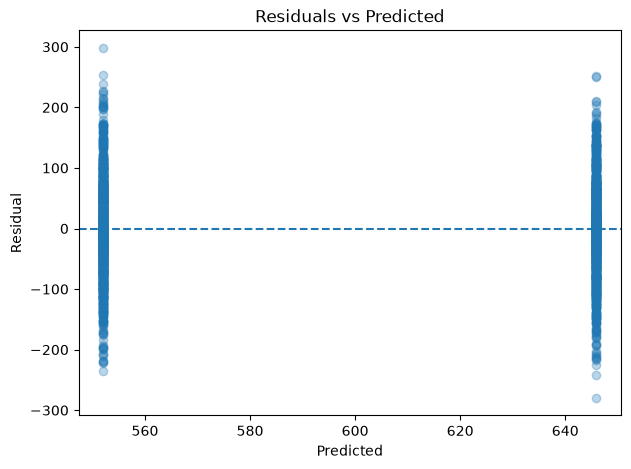

In [31]:
# Predicted values

data["predicted"] = mixed_results.predict(data)

# Residuals

data["residuals"] = (
    data["reaction_time"]
    - data["predicted"]
)

# Residual plot

plt.figure(figsize=(7, 5))

plt.scatter(
    data["predicted"],
    data["residuals"],
    alpha=0.30,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")

plt.show()

In [32]:
# Model Comparison

comparison = pd.DataFrame(
    {
        "Model": ["OLS", "Mixed Effects",],
        "AIC": [ols_model.aic, mixed_results.aic,],
        "BIC": [ols_model.bic, mixed_results.bic,],
        "Log Likelihood": [ols_model.llf, mixed_results.llf,],
    }
)

print("Model Comparison\n", comparison)

Model Comparison
            Model          AIC           BIC  Log Likelihood
0            OLS  27868.73848  27880.304928   -13932.369240
1  Mixed Effects          NaN           NaN   -13928.639573


In [33]:
# Estimated Marginal Means

estimated_means = (data.groupby("condition")["predicted"].mean())

print("Estimated Marginal Means\n", estimated_means)

Estimated Marginal Means
 condition
Congruent      552.062658
Incongruent    645.935483
Name: predicted, dtype: float64
